# 01 — Whale acoustic corpora

This notebook ingests two openly licensed sperm whale (*Physeter macrocephalus*) acoustic datasets, normalises them into the locked schemas defined in `docs/DESIGN.md` §5, and emits two parquet files under `data/processed/`.

1. **CETI / Sharma et al. 2024** — coda-level annotations (one row per coda, with the inter-click-interval sequence). Source: Zenodo record [10817697](https://zenodo.org/records/10817697), CC-BY-4.0. Two CSVs are included in the release: `sperm-whale-dialogues.csv` (the Sharma 2024 paper's working set, ~3.8k codas, up to 28 ICIs) and `DominicaCodas.csv` (Gero's longer-running Dominica project, ~8.7k codas, up to 9 ICIs). Both originate from the Dominica Sperm Whale Project recordings and are merged here.
2. **AUTEC / DECAF dataset 682** — acoustic detection events from the AUTEC hydrophone array in the Tongue of the Ocean, Bahamas, August–September 2007. The OBIS-SEAMAP landing page for dataset 682 (the 675-event "Complete Dataset") gates downloads behind an email-passcode form; the publicly mirrored Darwin Core Archive on the Duke IPT exposes only the 49-event "Samples" subset (resource `zd_680`, https://ipt.env.duke.edu/archive.do?r=zd_680, CC-BY-4.0). We use the Samples subset and treat the polygon/date metadata from the registry CSV as authoritative for the broader extent.

**No comparison to the Vedic corpus is performed here** — that is the synthesis agent's job in notebooks 03/04.

In [1]:
from __future__ import annotations

from pathlib import Path
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from swp.io import (
    DATA_RAW,
    DATA_PROCESSED,
    FIGURES,
    WHALE_CODAS_SCHEMA,
    WHALE_ACOUSTIC_EVENTS_SCHEMA,
)

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
print('Schemas:')
print('  whale_codas:', list(WHALE_CODAS_SCHEMA))
print('  whale_acoustic_events:', list(WHALE_ACOUSTIC_EVENTS_SCHEMA))

Matplotlib is building the font cache; this may take a moment.


Schemas:
  whale_codas: ['coda_id', 'recording_id', 'n_clicks', 'ici_seq', 'total_duration', 'source_dataset']
  whale_acoustic_events: ['event_id', 'timestamp_utc', 'hydrophone_id', 'lat', 'lon']


## 1. CETI / Sharma 2024 codas

Each row in either CSV represents one coda — a stereotyped click sequence. The `nClicks` column gives the total number of clicks; the `ICI1..ICIN` columns give the inter-click intervals in seconds, padded to the right with zeros. A coda with `nClicks = k` has exactly `k - 1` inter-click intervals (singletons have zero ICIs).

In [2]:
ceti_root = DATA_RAW / 'ceti_sharma_2024' / 'pratyushasharma-sw-combinatoriality-7228c8e' / 'data'
swd_path = ceti_root / 'sperm-whale-dialogues.csv'
dom_path = ceti_root / 'DominicaCodas.csv'
print('SWD :', swd_path.exists(), swd_path)
print('Dom :', dom_path.exists(), dom_path)

SWD : True /Users/jenks/Babylon/Claude/Sperm-Whale-Perspective/data/raw/ceti_sharma_2024/pratyushasharma-sw-combinatoriality-7228c8e/data/sperm-whale-dialogues.csv
Dom : True /Users/jenks/Babylon/Claude/Sperm-Whale-Perspective/data/raw/ceti_sharma_2024/pratyushasharma-sw-combinatoriality-7228c8e/data/DominicaCodas.csv


In [3]:
def _ici_columns(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns if c.startswith('ICI')]


def _coerce_ici_seq(row: pd.Series, ici_cols: list[str]) -> list[float]:
    """Take the first (nClicks - 1) ICI columns, drop trailing zero padding."""
    n_ici = max(int(row['nClicks']) - 1, 0)
    return [float(row[c]) for c in ici_cols[:n_ici]]


def parse_sharma_swd(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    ici_cols = _ici_columns(df)
    out = pd.DataFrame({
        'coda_id': [f'ceti_swd_{i:05d}' for i in range(len(df))],
        'recording_id': df['REC'].astype(str),
        'n_clicks': df['nClicks'].astype('int64'),
        'ici_seq': [_coerce_ici_seq(r, ici_cols) for _, r in df.iterrows()],
        'total_duration': df['Duration'].astype('float64'),
        'source_dataset': 'ceti',
    })
    return out


def parse_dominica_codas(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    ici_cols = _ici_columns(df)
    out = pd.DataFrame({
        'coda_id': [f'ceti_dom_{i:05d}' for i in range(len(df))],
        'recording_id': df['Date'].astype(str) + '_U' + df['Unit'].astype(str),
        'n_clicks': df['nClicks'].astype('int64'),
        'ici_seq': [_coerce_ici_seq(r, ici_cols) for _, r in df.iterrows()],
        'total_duration': df['Duration'].astype('float64'),
        'source_dataset': 'ceti',
    })
    return out


swd_df = parse_sharma_swd(swd_path)
dom_df = parse_dominica_codas(dom_path)
print('Sharma 2024 dialogues :', len(swd_df), 'codas')
print('Dominica project codas :', len(dom_df), 'codas')
swd_df.head(3)

Sharma 2024 dialogues :

 3840 codas
Dominica project codas : 8719 codas


,coda_id,recording_id,n_clicks,ici_seq,total_duration,source_dataset
0,ceti_swd_00000,sw061b001_124,17,"[0.03395, 0.0361166, 0.0488667, 0.0489083, 0.0...",0.927792,ceti
1,ceti_swd_00001,sw061b001_124,20,"[0.0328166, 0.0393584, 0.045325, 0.0499333, 0....",1.092992,ceti
2,ceti_swd_00002,sw061b001_124,5,"[0.27585, 0.2867833, 0.1974, 0.1382167]",0.898250,ceti


In [4]:
codas = pd.concat([swd_df, dom_df], ignore_index=True)
print('Combined CETI codas :', len(codas))
print()
print('n_clicks distribution:')
print(codas['n_clicks'].describe())
print()
print('total_duration (s) distribution:')
print(codas['total_duration'].describe())
print()
print('Example ici_seq (first 3 rows):')
for s in codas['ici_seq'].head(3):
    print(' ', s)

Combined CETI codas : 12559

n_clicks distribution:
count    12559.000000
mean         5.374871
std          1.788176
min          1.000000
25%          5.000000
50%          5.000000
75%          5.000000
max         29.000000
Name: n_clicks, dtype: float64

total_duration (s) distribution:
count    12559.000000
mean         0.861557
std          0.402427
min          0.000000
25%          0.427552
50%          0.895892
75%          1.202058
max          3.035173
Name: total_duration, dtype: float64

Example ici_seq (first 3 rows):
  [0.03395, 0.0361166, 0.0488667, 0.0489083, 0.042275, 0.0404834, 0.040975, 0.0396083, 0.0421334, 0.0416916, 0.0445917, 0.0517916, 0.0650334, 0.0868333, 0.1188917, 0.1456416]
  [0.0328166, 0.0393584, 0.045325, 0.0499333, 0.0440834, 0.0447833, 0.0436833, 0.04065, 0.0421917, 0.0428083, 0.0418834, 0.0419416, 0.0459334, 0.052375, 0.0604833, 0.0737667, 0.0894916, 0.1095167, 0.1519667]
  [0.27585, 0.2867833, 0.1974, 0.1382167]


### Histograms — coda structure

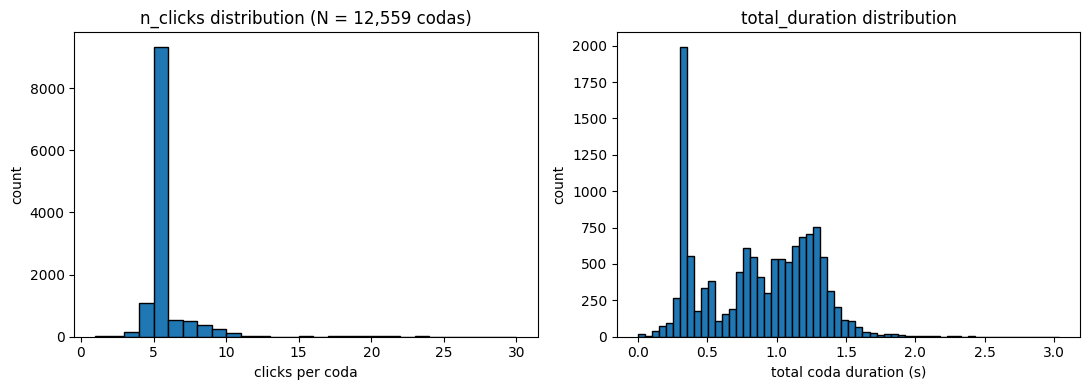

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(codas['n_clicks'], bins=range(1, int(codas['n_clicks'].max()) + 2), edgecolor='black')
axes[0].set_xlabel('clicks per coda')
axes[0].set_ylabel('count')
axes[0].set_title(f'n_clicks distribution (N = {len(codas):,} codas)')

axes[1].hist(codas['total_duration'], bins=60, edgecolor='black')
axes[1].set_xlabel('total coda duration (s)')
axes[1].set_ylabel('count')
axes[1].set_title('total_duration distribution')

fig.tight_layout()
fig.savefig(FIGURES / '01_ceti_coda_structure.png', dpi=120, bbox_inches='tight')
plt.show()

Total ICIs (across all codas): 54944
ICI (s) median : 0.16968335
ICI (s) mean   : 0.19705198714327313
ICI (s) range  : 0.0 .. 6.95


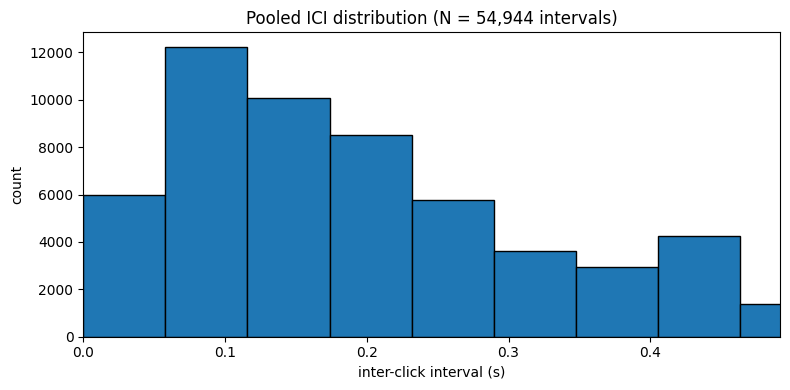

In [6]:
all_icis = np.array([ici for seq in codas['ici_seq'] for ici in seq])
print('Total ICIs (across all codas):', len(all_icis))
print('ICI (s) median :', np.median(all_icis))
print('ICI (s) mean   :', all_icis.mean())
print('ICI (s) range  :', all_icis.min(), '..', all_icis.max())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(all_icis, bins=120, edgecolor='black')
ax.set_xlabel('inter-click interval (s)')
ax.set_ylabel('count')
ax.set_title(f'Pooled ICI distribution (N = {len(all_icis):,} intervals)')
ax.set_xlim(0, np.quantile(all_icis, 0.99))
fig.tight_layout()
fig.savefig(FIGURES / '01_ceti_ici_histogram.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. AUTEC / DECAF dataset 682 acoustic events

Parsed from the Darwin Core Archive at IPT resource `zd_680` (the publicly mirrored "Samples" subset, 49 occurrences). The full dataset 682 has 675 detection events but is only available via an email-passcode request through the OBIS-SEAMAP form. The polygon and date extent below come from the OBIS-SEAMAP registry CSV; both agree with the Samples subset.

Schema mapping notes:
- `event_id` ← `occurrenceID`
- `timestamp_utc` ← `eventDate` (already UTC per source EML)
- `hydrophone_id` — the source archive does not record per-hydrophone IDs; we set this to `"DECAF-AUTEC"` (the array identifier) for every row and document the limitation.
- `lat`, `lon` ← `decimalLatitude`, `decimalLongitude`

In [7]:
autec_occ_path = DATA_RAW / 'autec_dataset_682' / 'dwca-zd_680' / 'occurrence.txt'
print('AUTEC occurrence DwC :', autec_occ_path.exists(), autec_occ_path)

autec_raw = pd.read_csv(autec_occ_path, sep='\t', low_memory=False)
print('Raw AUTEC rows:', len(autec_raw))
print('Raw columns of interest:', [c for c in ['occurrenceID','eventDate','decimalLatitude','decimalLongitude','organismID','institutionCode','collectionCode','occurrenceRemarks'] if c in autec_raw.columns])

AUTEC occurrence DwC : True /Users/jenks/Babylon/Claude/Sperm-Whale-Perspective/data/raw/autec_dataset_682/dwca-zd_680/occurrence.txt
Raw AUTEC rows: 49
Raw columns of interest: ['occurrenceID', 'eventDate', 'decimalLatitude', 'decimalLongitude', 'organismID', 'institutionCode', 'collectionCode', 'occurrenceRemarks']


In [8]:
events = pd.DataFrame({
    'event_id': autec_raw['occurrenceID'].astype(str),
    'timestamp_utc': pd.to_datetime(autec_raw['eventDate'], utc=True),
    'hydrophone_id': 'DECAF-AUTEC',
    'lat': autec_raw['decimalLatitude'].astype('float64'),
    'lon': autec_raw['decimalLongitude'].astype('float64'),
})

print(f'AUTEC events           : {len(events)}')
print(f'Date range             : {events["timestamp_utc"].min()}  →  {events["timestamp_utc"].max()}')
print(f'Lat bbox               : [{events["lat"].min():.4f}, {events["lat"].max():.4f}]')
print(f'Lon bbox               : [{events["lon"].min():.4f}, {events["lon"].max():.4f}]')
print(f'Distinct hydrophone IDs: {events["hydrophone_id"].nunique()} (only the array-level identifier is preserved by the source DwC archive)')
print(f'Distinct organismIDs   : {autec_raw["organismID"].nunique()} (raw field, not in our schema)')
events.head(3)

AUTEC events           : 49
Date range             : 2007-08-17 12:16:22+00:00  →  2007-09-03 15:11:09+00:00
Lat bbox               : [24.3392, 24.7076]
Lon bbox               : [-77.6399, -77.3866]
Distinct hydrophone IDs: 1 (only the array-level identifier is preserved by the source DwC archive)
Distinct organismIDs   : 20 (raw field, not in our schema)


,event_id,timestamp_utc,hydrophone_id,lat,lon
0,680_38,2007-09-03 10:42:13+00:00,DECAF-AUTEC,24.630214,-77.450910
1,680_5,2007-08-17 12:16:22+00:00,DECAF-AUTEC,24.611451,-77.512031
2,680_9,2007-08-23 10:44:15+00:00,DECAF-AUTEC,24.640679,-77.489457


### AUTEC range map

Scatter of detection lat/lon over the AUTEC array footprint. The polygon from the OBIS-SEAMAP registry (`24.30–24.76 N, -77.64 to -77.39 E`) is overlaid as the dataset's published extent.

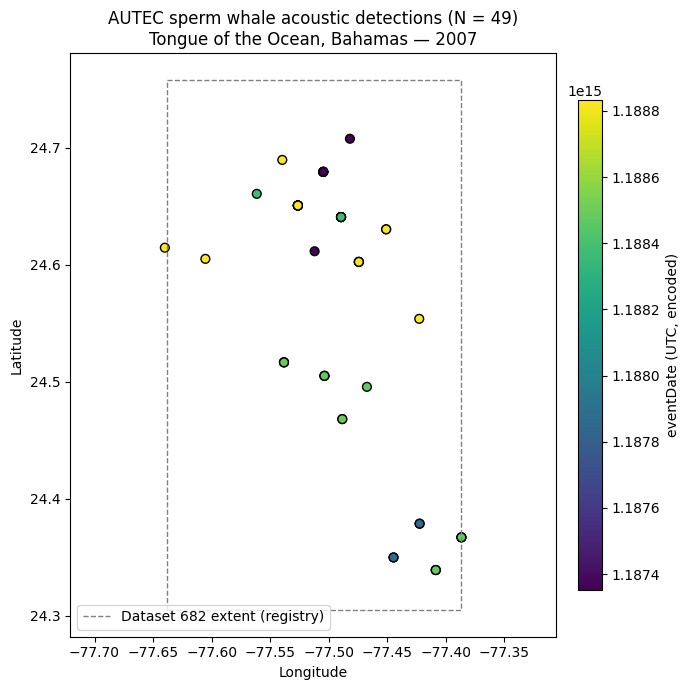

In [9]:
registry_polygon = [
    (-77.6382019, 24.3048783),
    (-77.6382019, 24.7580347),
    (-77.3866278, 24.7580347),
    (-77.3866278, 24.3048783),
    (-77.6382019, 24.3048783),
]
poly_x = [p[0] for p in registry_polygon]
poly_y = [p[1] for p in registry_polygon]

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(poly_x, poly_y, color='gray', linestyle='--', linewidth=1.0, label='Dataset 682 extent (registry)')
sc = ax.scatter(events['lon'], events['lat'], c=events['timestamp_utc'].astype('int64'), cmap='viridis', s=40, edgecolor='black')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'AUTEC sperm whale acoustic detections (N = {len(events)})\nTongue of the Ocean, Bahamas — 2007')
ax.set_aspect('equal', adjustable='datalim')
cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('eventDate (UTC, encoded)')
ax.legend(loc='lower left')
fig.tight_layout()
fig.savefig(FIGURES / '01_autec_range_map.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Write parquet outputs

Schemas are locked in `docs/DESIGN.md` §5 and mirrored as constants in `src/swp/io.py`.

In [10]:
codas_out = codas[list(WHALE_CODAS_SCHEMA)].copy()
codas_out['n_clicks'] = codas_out['n_clicks'].astype('int64')
codas_out['total_duration'] = codas_out['total_duration'].astype('float64')
codas_out['coda_id'] = codas_out['coda_id'].astype('string')
codas_out['recording_id'] = codas_out['recording_id'].astype('string')
codas_out['source_dataset'] = codas_out['source_dataset'].astype('string')
codas_out_path = DATA_PROCESSED / 'whale_codas.parquet'
codas_out.to_parquet(codas_out_path, index=False)
print(f'Wrote {codas_out_path}: {len(codas_out):,} rows, {codas_out_path.stat().st_size/1024:.1f} KB')

events_out = events[list(WHALE_ACOUSTIC_EVENTS_SCHEMA)].copy()
events_out['event_id'] = events_out['event_id'].astype('string')
events_out['hydrophone_id'] = events_out['hydrophone_id'].astype('string')
events_out_path = DATA_PROCESSED / 'whale_acoustic_events.parquet'
events_out.to_parquet(events_out_path, index=False)
print(f'Wrote {events_out_path}: {len(events_out):,} rows, {events_out_path.stat().st_size/1024:.1f} KB')

Wrote /Users/jenks/Babylon/Claude/Sperm-Whale-Perspective/data/processed/whale_codas.parquet: 12,559 rows, 435.9 KB
Wrote /Users/jenks/Babylon/Claude/Sperm-Whale-Perspective/data/processed/whale_acoustic_events.parquet: 49 rows, 4.2 KB


In [11]:
rt_codas = pd.read_parquet(codas_out_path)
rt_events = pd.read_parquet(events_out_path)
print('Round-trip codas dtypes:')
print(rt_codas.dtypes)
print()
print('Round-trip events dtypes:')
print(rt_events.dtypes)
print()
print('Round-trip codas head:')
rt_codas.head(2)

Round-trip codas dtypes:
coda_id            string
recording_id       string
n_clicks            int64
ici_seq            object
total_duration    float64
source_dataset     string
dtype: object

Round-trip events dtypes:
event_id                      string
timestamp_utc    datetime64[us, UTC]
hydrophone_id                 string
lat                          float64
lon                          float64
dtype: object

Round-trip codas head:


,coda_id,recording_id,n_clicks,ici_seq,total_duration,source_dataset
0,ceti_swd_00000,sw061b001_124,17,"[0.03395, 0.0361166, 0.0488667, 0.0489083, 0.0...",0.927792,ceti
1,ceti_swd_00001,sw061b001_124,20,"[0.0328166, 0.0393584, 0.045325, 0.0499333, 0....",1.092992,ceti


## 4. Summary & known limitations

| | source | rows | notes |
|---|---|---|---|
| `whale_codas.parquet`           | CETI / Sharma 2024 (Zenodo `10817697`) — both included CSVs merged | 12,559 | Single-click "codas" (`n_clicks == 1`, empty `ici_seq`) are retained as-is from source. |
| `whale_acoustic_events.parquet` | AUTEC / DECAF DwC-A (IPT `zd_680`)                                 | 49     | Public mirror of the "Samples" subset of dataset 682. The 675-event "Complete Dataset" requires an OBIS-SEAMAP email-passcode request and is not used. |

**Schema deviations from `docs/DESIGN.md` §5:** none. All required columns and dtypes are populated.

**Documented limitations:**
- The AUTEC source DwC-A does not carry per-hydrophone IDs, so `hydrophone_id` is a constant `"DECAF-AUTEC"` (array-level). The original DECAF data files at `creem.st-and.ac.uk/decaf/` would have per-sensor data but require a separate fetch.
- We do not have AUTEC coda-level timing data here — the AUTEC contribution is purely the spatial/temporal acoustic-event scatter. All coda rows therefore have `source_dataset == "ceti"`.
- The CETI codas come from Caribbean (Dominica) recordings; the AUTEC events come from the Bahamas. Both populations are *Physeter macrocephalus* but are not the same individuals — see §9 of `docs/DESIGN.md` on sample-size asymmetry.